In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df1=pd.read_csv("api_data_aadhar_enrolment_0_500000.csv")
df2=pd.read_csv("api_data_aadhar_enrolment_500000_1000000.csv")
df3=pd.read_csv("api_data_aadhar_enrolment_1000000_1006029.csv")


In [4]:
print("size of df1: ",df1.shape)
print("size of df2: ",df2.shape)
print("size of df3: ",df3.shape)

size of df1:  (500000, 7)
size of df2:  (500000, 7)
size of df3:  (6029, 7)


In [5]:
df_comb=pd.concat([df1,df2,df3], ignore_index=True)
df_comb

,date,state,district,pincode,age_0_5,age_5_17,age_18_greater
0,02-03-2025,Meghalaya,East Khasi Hills,793121,11,61,37
1,09-03-2025,Karnataka,Bengaluru Urban,560043,14,33,39
2,09-03-2025,Uttar Pradesh,Kanpur Nagar,208001,29,82,12
3,09-03-2025,Uttar Pradesh,Aligarh,202133,62,29,15
4,09-03-2025,Karnataka,Bengaluru Urban,560016,14,16,21
...,...,...,...,...,...,...,...
1006024,31-12-2025,West Bengal,West Midnapore,721149,2,0,0
1006025,31-12-2025,West Bengal,West Midnapore,721150,2,2,0
1006026,31-12-2025,West Bengal,West Midnapore,721305,0,1,0
1006027,31-12-2025,West Bengal,West Midnapore,721504,1,0,0


In [6]:
df_comb['state'] = (
    df_comb['state']
    .astype(str)
    .str.strip()
    .str.title()
)


In [7]:
df_comb.head()

,date,state,district,pincode,age_0_5,age_5_17,age_18_greater
0,02-03-2025,Meghalaya,East Khasi Hills,793121,11,61,37
1,09-03-2025,Karnataka,Bengaluru Urban,560043,14,33,39
2,09-03-2025,Uttar Pradesh,Kanpur Nagar,208001,29,82,12
3,09-03-2025,Uttar Pradesh,Aligarh,202133,62,29,15
4,09-03-2025,Karnataka,Bengaluru Urban,560016,14,16,21


In [8]:
df_comb['state'].value_counts()

state
Uttar Pradesh                                   110369
Tamil Nadu                                       92552
Maharashtra                                      77191
West Bengal                                      76530
Karnataka                                        70198
Andhra Pradesh                                   65663
Bihar                                            60567
Rajasthan                                        56159
Madhya Pradesh                                   50225
Gujarat                                          46624
Odisha                                           43692
Telangana                                        42774
Kerala                                           39145
Assam                                            31827
Jharkhand                                        23218
Punjab                                           20439
Chhattisgarh                                     18550
Haryana                                          15997
Jamm

In [9]:
state_corrections = {
    'West Bengal': 'West Bengal',
    'West Bangal': 'West Bengal',
    'Westbengal': 'West Bengal',
    'West  Bengal':'West Bengal',
    'Dadra And Nagar Haveli':'Dadra And Nagar Haveli And Daman And Diu',
    'Daman And Diu':'Dadra And Nagar Haveli And Daman And Diu',
    'Dadra & Nagar Haveli':'Dadra And Nagar Haveli And Daman And Diu',
    'Daman & Diu':'Dadra And Nagar Haveli And Daman And Diu',
    'The Dadra And Nagar Haveli And Daman And Diu':'Dadra And Nagar Haveli And Daman And Diu',
    'Andaman And Nicobar Islands':'Andaman & Nicobar Islands',
    'Jammu And Kashmir':'Jammu & Kashmir'

}

df_comb['state'] = df_comb['state'].replace(state_corrections)


In [10]:
df_comb['state'].value_counts()

state
Uttar Pradesh                               110369
Tamil Nadu                                   92552
Maharashtra                                  77191
West Bengal                                  76561
Karnataka                                    70198
Andhra Pradesh                               65663
Bihar                                        60567
Rajasthan                                    56159
Madhya Pradesh                               50225
Gujarat                                      46624
Odisha                                       43692
Telangana                                    42774
Kerala                                       39145
Assam                                        31827
Jharkhand                                    23218
Punjab                                       20439
Chhattisgarh                                 18550
Haryana                                      15997
Jammu & Kashmir                              11455
Himachal Pradesh         

In [11]:
df_comb = df_comb[df_comb['state'] != '100000']

In [12]:
df_comb['state'].value_counts()

state
Uttar Pradesh                               110369
Tamil Nadu                                   92552
Maharashtra                                  77191
West Bengal                                  76561
Karnataka                                    70198
Andhra Pradesh                               65663
Bihar                                        60567
Rajasthan                                    56159
Madhya Pradesh                               50225
Gujarat                                      46624
Odisha                                       43692
Telangana                                    42774
Kerala                                       39145
Assam                                        31827
Jharkhand                                    23218
Punjab                                       20439
Chhattisgarh                                 18550
Haryana                                      15997
Jammu & Kashmir                              11455
Himachal Pradesh         

we see that UP has the state with the highest enrolment.

In [13]:
df_comb['district']=df_comb['district'].str.strip().str.title()

C:\Users\user\AppData\Local\Temp\ipykernel_4412\145597546.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_comb['district']=df_comb['district'].str.strip().str.title()


In [14]:
UP=df_comb[df_comb['state']=='Uttar Pradesh']
UP

,date,state,district,pincode,age_0_5,age_5_17,age_18_greater
2,09-03-2025,Uttar Pradesh,Kanpur Nagar,208001,29,82,12
3,09-03-2025,Uttar Pradesh,Aligarh,202133,62,29,15
7,09-03-2025,Uttar Pradesh,Bahraich,271865,26,60,14
8,09-03-2025,Uttar Pradesh,Firozabad,283204,28,26,10
10,09-03-2025,Uttar Pradesh,Maharajganj,273164,31,70,13
...,...,...,...,...,...,...,...
1005743,31-12-2025,Uttar Pradesh,Varanasi,221002,10,18,0
1005744,31-12-2025,Uttar Pradesh,Varanasi,221104,4,11,0
1005745,31-12-2025,Uttar Pradesh,Varanasi,221107,1,15,0
1005746,31-12-2025,Uttar Pradesh,Varanasi,221207,1,9,0


In [15]:
UP['district'].value_counts()

district
Azamgarh        2967
Lucknow         2933
Jaunpur         2689
Allahabad       2626
Kanpur Nagar    2601
                ... 
Kushinagar *       6
Shravasti          4
Raebareli          2
Kushi Nagar        1
Bagpat             1
Name: count, Length: 89, dtype: int64

In UP, Azamargh has the highest enrolment.

In [16]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [17]:
UP.groupby('district')['pincode'].value_counts()

district                    pincode
Agra                        282001     86
                            282006     79
                            282007     79
                            283201     75
                            282005     75
                            282010     75
                            282009     73
                            283105     73
                            283111     73
                            282002     73
                            283110     72
                            283102     72
                            283104     72
                            282004     72
                            283125     71
                            282003     71
                            283101     70
                            283126     70
                            283114     69
                            283122     68
                            283123     67
                            283113     67
                            283202     6

Azamargh also conveniently has the most number of pincodes.

In [18]:
print("Age>18 enrollments in Azamgarh: ",UP[UP['district'] == 'Azamgarh']['age_18_greater'].sum())
print("Age 5 to 17 enrollments in Azamgarh: ",UP[UP['district'] == 'Azamgarh']['age_5_17'].sum())
print("Age 0 to 5 enrollments in Azamgarh: ",UP[UP['district'] == 'Azamgarh']['age_0_5'].sum())

Age>18 enrollments in Azamgarh:  279
Age 5 to 17 enrollments in Azamgarh:  13577
Age 0 to 5 enrollments in Azamgarh:  6717


Highest enrollments occur for school going children as indicated by the age group 5 to 7. Early enrollment also is stronh in Azamgarh(0 to 5). High saturation for adults though.

In [19]:
print("Age>18 enrollments in UP: ",df_comb[df_comb['state'] == 'Uttar Pradesh']['age_18_greater'].sum())
print("Age5 to 17 enrollments in UP: ",df_comb[df_comb['state'] == 'Uttar Pradesh']['age_5_17'].sum())
print("Age 0 to 5 enrollments in UP: ",df_comb[df_comb['state'] == 'Uttar Pradesh']['age_0_5'].sum())

Age>18 enrollments in UP:  17902
Age5 to 17 enrollments in UP:  479682
Age 0 to 5 enrollments in UP:  521045


But overall in UP, enrollments for babies and toddlers are more.It shows strong early enrollments and parental awareness.

In [20]:
print("Age>18 enrollments in Tamil Nadu: ",df_comb[df_comb['state'] == 'Tamil Nadu']['age_18_greater'].sum())
print("Age5 to 17 enrollments in Tamil Nadu: ",df_comb[df_comb['state'] == 'Tamil Nadu']['age_5_17'].sum())
print("Age 0 to 5 enrollments in Tamil Nadu: ",df_comb[df_comb['state'] == 'Tamil Nadu']['age_0_5'].sum())

Age>18 enrollments in Tamil Nadu:  1249
Age5 to 17 enrollments in Tamil Nadu:  37227
Age 0 to 5 enrollments in Tamil Nadu:  182313


In [21]:
print("Age>18 enrollments in Maharashtra: ",df_comb[df_comb['state'] == 'Maharashtra']['age_18_greater'].sum())
print("Age5 to 17 enrollments in Maharashtra: ",df_comb[df_comb['state'] == 'Maharashtra']['age_5_17'].sum())
print("Age 0 to 5 enrollments in Maharashtra: ",df_comb[df_comb['state'] == 'Maharashtra']['age_0_5'].sum())

Age>18 enrollments in Maharashtra:  8209
Age5 to 17 enrollments in Maharashtra:  82116
Age 0 to 5 enrollments in Maharashtra:  278814


In [22]:
print("Age>18 enrollments in Lakshadweep: ",df_comb[df_comb['state'] == 'Lakshadweep']['age_18_greater'].sum())
print("Age5 to 17 enrollments in Lakshadweep: ",df_comb[df_comb['state'] == 'Lakshadweep']['age_5_17'].sum())
print("Age 0 to 5 enrollments in Lakshadweep: ",df_comb[df_comb['state'] == 'Lakshadweep']['age_0_5'].sum())

Age>18 enrollments in Lakshadweep:  1
Age5 to 17 enrollments in Lakshadweep:  10
Age 0 to 5 enrollments in Lakshadweep:  192


In [23]:
print("Age>18 enrollments in Ladakh: ",df_comb[df_comb['state'] == 'Ladakh']['age_18_greater'].sum())
print("Age5 to 17 enrollments in Ladakh: ",df_comb[df_comb['state'] == 'Ladakh']['age_5_17'].sum())
print("Age 0 to 5 enrollments in Ladakh: ",df_comb[df_comb['state'] == 'Ladakh']['age_0_5'].sum())

Age>18 enrollments in Ladakh:  18
Age5 to 17 enrollments in Ladakh:  133
Age 0 to 5 enrollments in Ladakh:  466


Lakshadweep and Ladakh are the states with lowest enrollments yet the same trend is followed.The most enrolled category is children between 0 to 17 while the adults getting enrolled are comparatively less. This could be due to population.

In [24]:
state_age = (
    df_comb
    .groupby('state')[['age_0_5', 'age_5_17', 'age_18_greater']]
    .sum()
    .reset_index()
)

state_age.head(20)


,state,age_0_5,age_5_17,age_18_greater
0,Andaman & Nicobar Islands,479,32,0
1,Andhra Pradesh,112445,13746,1495
2,Arunachal Pradesh,1957,2236,151
3,Assam,141235,66085,22877
4,Bihar,262875,334802,11908
5,Chandigarh,2476,211,36
6,Chhattisgarh,82453,18769,1997
7,Dadra And Nagar Haveli And Daman And Diu,1497,250,52
8,Delhi,69183,22296,3050
9,Goa,1916,254,163


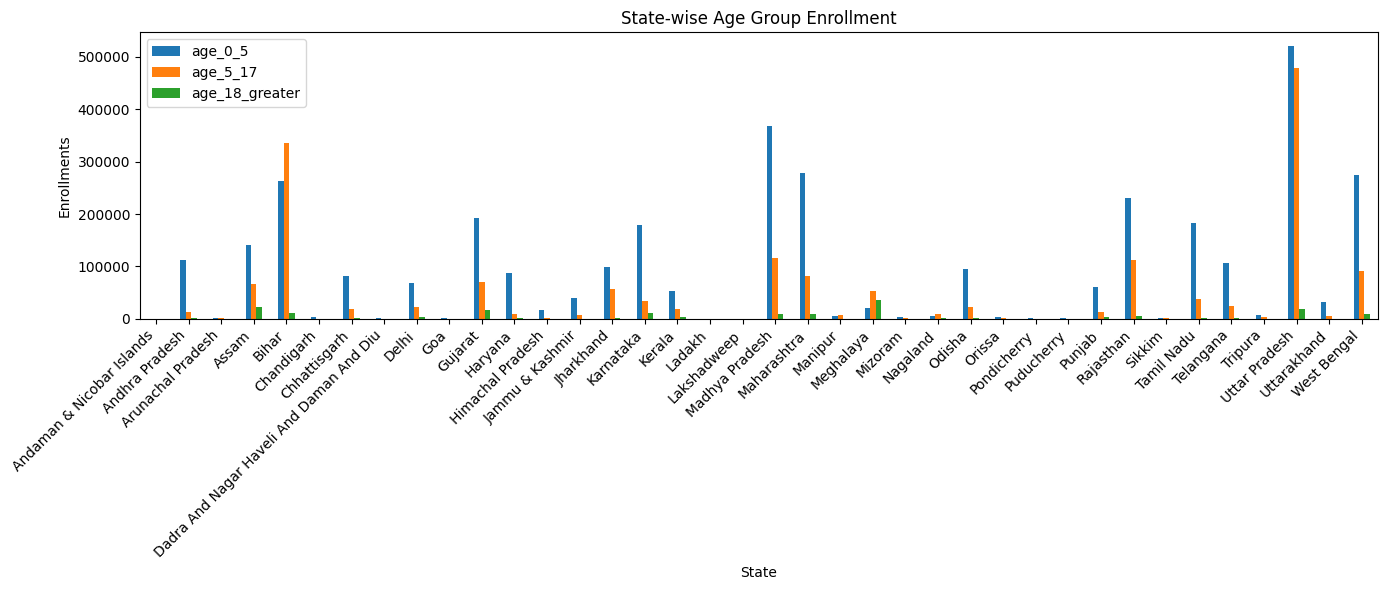

In [25]:
import matplotlib.pyplot as plt

state_age.set_index('state').plot(
    kind='bar',
    figsize=(14,6)
)

plt.xlabel("State")
plt.ylabel("Enrollments")
plt.title("State-wise Age Group Enrollment")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()



Although the trend of ages 0 to 5 is consistent across the country, UP,Madhya Pradesh, Maharashtra,West Bengal and Bihar are fairly high.

Bihar & Meghalaya, though, has a trend of children around age 5 to 17 enrolled more than age 0 to 5(an anomaly seen contrary to the common trend.) 

In [27]:
print("Age>18 enrollments in Meghalaya: ",df_comb[df_comb['state'] == 'Meghalaya']['age_18_greater'].sum())
print("Age5 to 17 enrollments in Meghalaya: ",df_comb[df_comb['state'] == 'Meghalaya']['age_5_17'].sum())
print("Age 0 to 5 enrollments in Meghalaya: ",df_comb[df_comb['state'] == 'Meghalaya']['age_0_5'].sum())


Age>18 enrollments in Meghalaya:  35287
Age5 to 17 enrollments in Meghalaya:  53305
Age 0 to 5 enrollments in Meghalaya:  21179


Meghalaya has more adult enrollments than early infants(0 to 5) enrollments.